In [ ]:
# Edit the sweep and initial states here. Gating also accepts length-N arrays.
G_values = np.arange(0.5, 2.5 + 0.25, 0.5)
initialization_seed = 1
rng = np.random.default_rng(initialization_seed)
initial_conditions = {
    "low": {"sn0": rng.uniform(0.0, 0.1, N), "sg0": rng.uniform(0.0, 0.1, N)},
    "high": {"sn0": rng.uniform(0.3, 1.0, N), "sg0": rng.uniform(0.3, 1.0, N)},
}
duration_s = 120.0
burn_in_s = 10.0
seed = 1
sigma = 0.00

# The simulator saves one firing-rate sample per millisecond (10 microsteps at dt=0.1 ms).
nb_steps = int(round(duration_s * 1000))
burn_in_steps = int(round(burn_in_s * 1000))
assert 0 <= burn_in_steps < nb_steps
assert np.all(np.diff(G_values) > 0)

# Store region means and decimated network traces, not every full rate array.
trace_stride = 10  # 10 ms between displayed trace samples
trace_time_s = (np.arange(0, nb_steps, trace_stride) + 1) / 1000
condition_names = list(initial_conditions)
mean_rate_e = np.empty((len(condition_names), len(G_values), N))
mean_rate_i = np.empty_like(mean_rate_e)
network_trace_e = np.empty((len(condition_names), len(G_values), len(trace_time_s)))
network_trace_i = np.empty_like(network_trace_e)

print(f"{len(condition_names) * len(G_values)} simulations, {duration_s:g} s each; "
      f"averages use the final {duration_s - burn_in_s:g} s.")

10 simulations, 120 s each; averages use the final 110 s.


## Single-node sweep of recurrent excitation and inhibition

Select node 0 and calculate its strength from the normalized full connectivity matrix.
Simulate that node alone with `G = 0`, `sigma = 0`, and plasticity/decay disabled.
Here `J = 1 + alpha * node_strength`: **G is intentionally omitted from this J rule**.
The model parameter `w` is the recurrent excitatory weight w+.

Reuse the selected node's low/high `sn0` and `sg0` draws from the settings above at every grid point.
Each heatmap entry is its excitatory firing rate averaged across time after burn-in
(10–120 s with the current settings), for one initial state per condition.
Both heatmaps share a color scale. The reported maximum is across grid points;
there is no maximization across time or random initial draws.


In [ ]:
node_index = 0  # Zero-based index in the original connectivity matrix
node_strength = float(C.sum(axis=0)[node_index])
JGABA_values = np.arange(1.6, 1.8 + 0.025, 0.025)
w_plus_values = np.arange(2.25, 2.75 + 0.025, 0.025)
node_conditions = ["low", "high"]
node_initial_conditions = {
    condition: {
        "sn0": float(initial_conditions[condition]["sn0"][node_index]),
        "sg0": float(initial_conditions[condition]["sg0"][node_index]),
    }
    for condition in node_conditions
}
node_mean_rate_e = np.empty((len(node_conditions), len(JGABA_values), len(w_plus_values)))

print(f"Node {node_index}: strength = {node_strength:.6f}")
print(f"Initial gating: {node_initial_conditions}")
print(f"G = sigma = 0; averaging {burn_in_s:g}–{duration_s:g} s")
node_sweep_start = perf_counter()
for JGABA_index, JGABA in enumerate(JGABA_values):
    node_J = JGABA
    for w_index, w_plus in enumerate(w_plus_values):
        for condition_index, condition in enumerate(node_conditions):
            node_params = dmf.default_params(
                C=np.zeros((1, 1)), G=0.0, sigma=0.0,
                J=node_J, w=float(w_plus), dt=0.1, seed=seed,
                with_plasticity=False, with_decay=False,
                return_rate=True, return_bold=False, return_fic=False,
                **node_initial_conditions[condition],
            )
            node_rates_e, node_rates_i, _, _ = dmf.run(node_params, nb_steps)
            if not (np.isfinite(node_rates_e).all() and np.isfinite(node_rates_i).all()):
                raise ValueError(f"Non-finite rates: JGABA={JGABA}, w+={w_plus}, {condition}")
            node_mean_rate_e[condition_index, JGABA_index, w_index] = (
                node_rates_e[0, burn_in_steps:].mean()
            )
            del node_rates_e, node_rates_i
    print(f"JGABA = {JGABA:g}, J = {node_J:.6f}: complete")
print(f"{node_mean_rate_e.size} simulations complete in {perf_counter() - node_sweep_start:.1f} s")


In [ ]:

node_vmax = max(float(node_mean_rate_e.max()), 1e-12)

# Add a third panel showing the high-minus-low difference
node_diff = node_mean_rate_e[1] - node_mean_rate_e[0]
node_diff_limit = max(float(np.abs(node_diff).max()), 1e-12)

node_fig, node_axes = plt.subplots(3, 1, figsize=(8, 25), sharex=True, sharey=True,
                                  layout="constrained")

for condition_index, (node_ax, condition) in enumerate(zip(node_axes[:2], node_conditions)):
    node_image = node_ax.imshow(node_mean_rate_e[condition_index], origin="lower",
                               aspect="auto", cmap="viridis", vmin=0, vmax=node_vmax)
    node_ax.set_xticks(np.arange(len(w_plus_values)), labels=w_plus_values)
    node_ax.set_yticks(np.arange(len(JGABA_values)), labels=JGABA_values)
    node_ax.set(xlabel="Recurrent excitation w+", title=f"{condition.capitalize()} initial conditions")
    node_ax.set_ylabel("Inhibitory coefficient JGABA" if condition_index == 0 else "")
    for JGABA_index in range(len(JGABA_values)):
        for w_index in range(len(w_plus_values)):
            value = node_mean_rate_e[condition_index, JGABA_index, w_index]
            node_ax.text(w_index, JGABA_index, f"{value:.2f}", ha="center", va="center",
                         color="white" if value < 0.5 * node_vmax else "black")
    peak_JGABA, peak_w = np.unravel_index(
        np.argmax(node_mean_rate_e[condition_index]), node_mean_rate_e[condition_index].shape
    )
    print(f"{condition}: maximum time-averaged rate = "
          f"{node_mean_rate_e[condition_index, peak_JGABA, peak_w]:.6f} Hz "
          f"at JGABA={JGABA_values[peak_JGABA]:g}, w+={w_plus_values[peak_w]:g}")

diff_ax = node_axes[2]
diff_image = diff_ax.imshow(node_diff, origin="lower", aspect="auto",
                           cmap="RdBu_r", vmin=-node_diff_limit, vmax=node_diff_limit)
diff_ax.set_xticks(np.arange(len(w_plus_values)), labels=w_plus_values)
diff_ax.set_yticks(np.arange(len(JGABA_values)), labels=JGABA_values)
diff_ax.set(xlabel="Recurrent excitation w+", title="High - low")
diff_ax.set_ylabel("Inhibitory coefficient JGABA")
for JGABA_index in range(len(JGABA_values)):
    for w_index in range(len(w_plus_values)):
        diff_value = node_diff[JGABA_index, w_index]
        diff_ax.text(w_index, JGABA_index, f"{diff_value:.2f}", ha="center", va="center",
                     color="white" if abs(diff_value) < 0.5 * node_diff_limit else "black")

node_fig.colorbar(node_image, ax=node_axes[:2], label="Time-averaged excitatory rate (Hz)")
node_fig.colorbar(diff_image, ax=node_axes[2], label="High - low rate (Hz)")
node_fig.suptitle(f"Node {node_index}, strength={node_strength:.4f}; G = sigma = 0")
plt.show()


## Find pairs meeting both rate criteria

Select grid points with **3 ≤ low-start mean rate ≤ 4 Hz** and
**high-start mean rate − low-start mean rate > 10 Hz**.
The means use the same post-burn-in time window as the single-node sweep.
The table is sorted by decreasing rate difference and includes the equivalent
`alpha = (JGABA - 1) / node_strength`.

These are matches on the tested grid for the two fixed initial states above,
not a guarantee for every draw from the low/high ranges. Change the grid in
the single-node sweep to refine the boundaries; no interpolation is used.


2 of 189 grid points satisfy 3 <= low rate <= 4 Hz and high - low > 10 Hz.
  w_plus    JGABA    alpha  low_rate_Hz  high_rate_Hz  high_minus_low_Hz
2.550000 1.725000 1.765288     3.047460     18.324383          15.276924
2.475000 1.675000 1.643544     3.233110     15.818403          12.585294


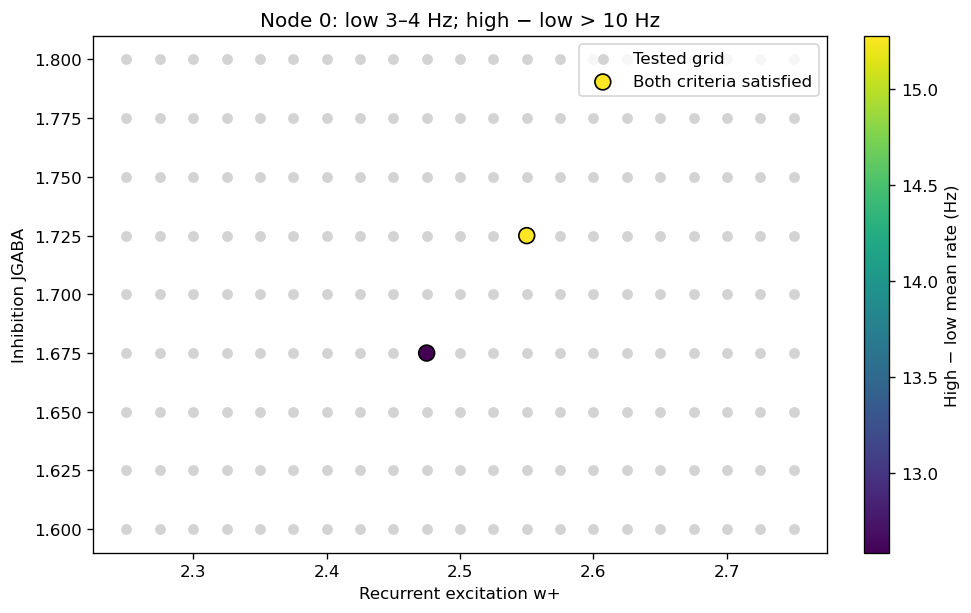

In [ ]:
# Apply both criteria to the time averages computed by the node sweep above.
low_rate_min = 3.0
low_rate_max = 4.0
minimum_rate_gap = 10.0

low_rates = node_mean_rate_e[node_conditions.index("low")]
high_rates = node_mean_rate_e[node_conditions.index("high")]
rate_gap = high_rates - low_rates
matching_pairs = (
    (low_rates >= low_rate_min)
    & (low_rates <= low_rate_max)
    & (rate_gap > minimum_rate_gap)
)
j_indices, w_indices = np.nonzero(matching_pairs)
qualifying_pairs = pd.DataFrame({
    "w_plus": w_plus_values[w_indices],
    "JGABA": JGABA_values[j_indices],
    "alpha": (JGABA_values[j_indices] - 1) / node_strength,
    "low_rate_Hz": low_rates[matching_pairs],
    "high_rate_Hz": high_rates[matching_pairs],
    "high_minus_low_Hz": rate_gap[matching_pairs],
}).sort_values("high_minus_low_Hz", ascending=False).reset_index(drop=True)

print(f"{len(qualifying_pairs)} of {matching_pairs.size} grid points satisfy "
      f"{low_rate_min:g} <= low rate <= {low_rate_max:g} Hz and "
      f"high - low > {minimum_rate_gap:g} Hz.")
if qualifying_pairs.empty:
    print("No matches on this grid. This does not exclude matches between grid points.")
else:
    print(qualifying_pairs.to_string(index=False, float_format=lambda value: f"{value:.6f}"))

pair_fig, pair_ax = plt.subplots(figsize=(8, 5), layout="constrained")
w_grid, j_grid = np.meshgrid(w_plus_values, JGABA_values)
pair_ax.scatter(w_grid, j_grid, color="lightgray", s=30, label="Tested grid")
if not qualifying_pairs.empty:
    pair_points = pair_ax.scatter(
        qualifying_pairs["w_plus"], qualifying_pairs["JGABA"],
        c=qualifying_pairs["high_minus_low_Hz"], cmap="viridis", s=90,
        edgecolors="black", label="Both criteria satisfied",
    )
    pair_fig.colorbar(pair_points, ax=pair_ax, label="High − low mean rate (Hz)")
pair_ax.set(xlabel="Recurrent excitation w+", ylabel="Inhibition JGABA",
            title=f"Node {node_index}: low {low_rate_min:g}–{low_rate_max:g} Hz; "
                  f"high − low > {minimum_rate_gap:g} Hz")
pair_ax.legend()
plt.show()
